# nb02 — SM8 Random Walk (GPU)

Research‑grade return‑probability generator for the SM8 cage.

This notebook:
- Loads a graph from an edge list
- Builds a compact CSR neighbor representation
- Runs a GPU‑accelerated random walk
- Computes the return probability P(t)
- Saves results to CSV
- Produces diagnostic plots


In [4]:
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device:", device, "-", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("WARNING: CUDA not available, using CPU only.")

Torch version: 2.5.1+cu121
CUDA available: True
Using device: cuda - NVIDIA GeForce RTX 3060 Ti


## Load Edge List (2‑Ring)

In [5]:
PROJECT_ROOT = Path(".").resolve()

# 2‑ring edge list
EDGE_LIST_PATH = PROJECT_ROOT / "nb02_SM8_tiled600_2ring_edgelist.txt"

# Output CSV
OUTPUT_CSV_PATH = PROJECT_ROOT / "nb02_SM8_600_2ring_return_prob.csv"

print("Edge list path:", EDGE_LIST_PATH)
print("Output CSV path:", OUTPUT_CSV_PATH)

def load_edge_list(path: Path):
    edges = []
    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) != 2:
                raise ValueError(f"Bad edge line: {line}")
            u, v = map(int, parts)
            edges.append((u, v))
    return np.array(edges, dtype=np.int64)

edges = load_edge_list(EDGE_LIST_PATH)
print("Loaded edges:", edges.shape)

min_vertex = edges.min()
if min_vertex != 0:
    print(f"Normalizing vertices by subtracting {min_vertex}")
    edges = edges - min_vertex

num_vertices = int(edges.max()) + 1
print("Number of vertices:", num_vertices)

Edge list path: C:\Users\DrThomas\Documents\GitHub\CPP\series_standard_model\notebooks\nb02_SM8_tiled600_2ring_edgelist.txt
Output CSV path: C:\Users\DrThomas\Documents\GitHub\CPP\series_standard_model\notebooks\nb02_SM8_600_2ring_return_prob.csv
Loaded edges: (59040, 2)
Number of vertices: 8160


## Build CSR Neighbor Structure

In [6]:
def build_neighbors_csr(num_vertices: int, edges: np.ndarray):
    deg = np.zeros(num_vertices, dtype=np.int64)
    for u, v in edges:
        deg[u] += 1
        deg[v] += 1

    offsets = np.zeros(num_vertices + 1, dtype=np.int64)
    offsets[1:] = np.cumsum(deg)

    neighbors_flat = np.empty(edges.shape[0] * 2, dtype=np.int64)
    cursor = offsets.copy()

    for u, v in edges:
        neighbors_flat[cursor[u]] = v
        cursor[u] += 1
        neighbors_flat[cursor[v]] = u
        cursor[v] += 1

    return neighbors_flat, offsets

neighbors_flat, offsets = build_neighbors_csr(num_vertices, edges)
print("neighbors_flat shape:", neighbors_flat.shape)
print("offsets shape:", offsets.shape)
print("Average degree:", neighbors_flat.shape[0] / num_vertices)

neighbors_flat shape: (118080,)
offsets shape: (8161,)
Average degree: 14.470588235294118


## GPU Random Walk

In [7]:
num_walkers = 100_000
max_steps   = 2_000
start_vertex = 0
rng_seed    = 12345

print("num_walkers:", num_walkers)
print("max_steps:", max_steps)
print("start_vertex:", start_vertex)
print("rng_seed:", rng_seed)

neighbors_flat_t = torch.from_numpy(neighbors_flat).to(device)
offsets_t        = torch.from_numpy(offsets).to(device)

walker_positions = torch.full(
    (num_walkers,),
    fill_value=start_vertex,
    device=device,
    dtype=torch.long,
)

generator = torch.Generator(device=device)
generator.manual_seed(rng_seed)

def random_walk_return_prob(neighbors_flat_t, offsets_t, walker_positions, start_vertex, max_steps, generator):
    num_walkers = walker_positions.shape[0]
    start_vertex_t = torch.tensor(start_vertex, device=walker_positions.device, dtype=torch.long)

    P_t = []

    with torch.no_grad():
        at_start = (walker_positions == start_vertex_t).sum().item()
        P_t.append(at_start / num_walkers)

    t0 = time.time()

    for t in range(1, max_steps + 1):
        offs = offsets_t[walker_positions]
        offs_next = offsets_t[walker_positions + 1]
        degrees = offs_next - offs

        r = torch.randint(
            low=0,
            high=degrees.max().item(),
            size=(num_walkers,),
            device=walker_positions.device,
            generator=generator,
        )

        r = torch.minimum(r, degrees - 1)

        neighbor_indices = offs + r
        walker_positions = neighbors_flat_t[neighbor_indices]

        at_start = (walker_positions == start_vertex_t).sum().item()
        P_t.append(at_start / num_walkers)

        if t % 100 == 0 or t == max_steps:
            elapsed = time.time() - t0
            print(f"t = {t:5d} / {max_steps}, P(t) = {P_t[-1]:.6e}, elapsed = {elapsed:.2f}s")

    return np.arange(0, max_steps + 1, dtype=np.float64), np.array(P_t, dtype=np.float64)

t_vals, P_vals = random_walk_return_prob(
    neighbors_flat_t,
    offsets_t,
    walker_positions,
    start_vertex,
    max_steps,
    generator,
)

num_walkers: 100000
max_steps: 2000
start_vertex: 0
rng_seed: 12345
t =   100 / 2000, P(t) = 8.000000e-05, elapsed = 0.10s
t =   200 / 2000, P(t) = 2.000000e-05, elapsed = 0.14s
t =   300 / 2000, P(t) = 1.000000e-05, elapsed = 0.17s
t =   400 / 2000, P(t) = 0.000000e+00, elapsed = 0.21s
t =   500 / 2000, P(t) = 0.000000e+00, elapsed = 0.24s
t =   600 / 2000, P(t) = 0.000000e+00, elapsed = 0.28s
t =   700 / 2000, P(t) = 0.000000e+00, elapsed = 0.32s
t =   800 / 2000, P(t) = 0.000000e+00, elapsed = 0.36s
t =   900 / 2000, P(t) = 0.000000e+00, elapsed = 0.39s
t =  1000 / 2000, P(t) = 0.000000e+00, elapsed = 0.43s
t =  1100 / 2000, P(t) = 0.000000e+00, elapsed = 0.47s
t =  1200 / 2000, P(t) = 0.000000e+00, elapsed = 0.50s
t =  1300 / 2000, P(t) = 0.000000e+00, elapsed = 0.54s
t =  1400 / 2000, P(t) = 0.000000e+00, elapsed = 0.58s
t =  1500 / 2000, P(t) = 0.000000e+00, elapsed = 0.61s
t =  1600 / 2000, P(t) = 0.000000e+00, elapsed = 0.65s
t =  1700 / 2000, P(t) = 0.000000e+00, elapsed = 0.6

## Save CSV

In [8]:
df = pd.DataFrame({"t": t_vals, "P": P_vals})
df.to_csv(OUTPUT_CSV_PATH, index=False)
print("Wrote return probability data to:", OUTPUT_CSV_PATH)
df.head()

Wrote return probability data to: C:\Users\DrThomas\Documents\GitHub\CPP\series_standard_model\notebooks\nb02_SM8_600_2ring_return_prob.csv


,t,P
0,0.0,1.00000
1,1.0,0.00000
2,2.0,0.05462
3,3.0,0.01221
4,4.0,0.01046


## Diagnostic Plots

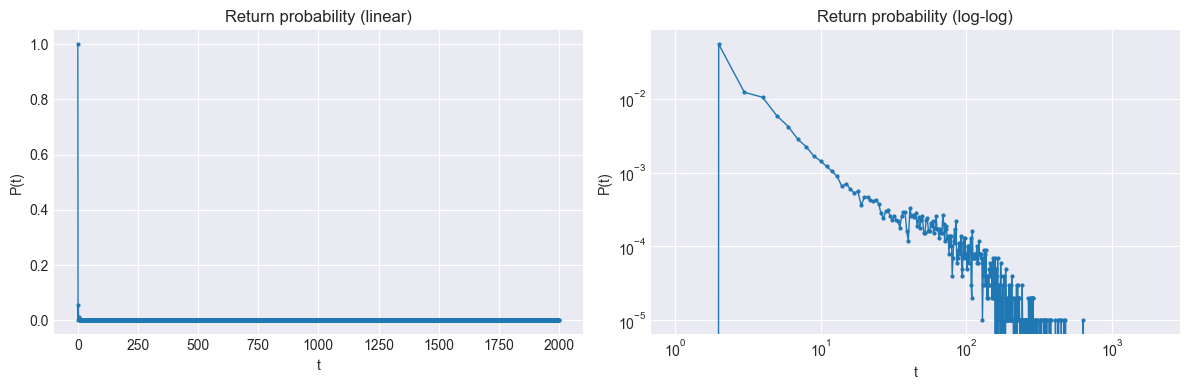

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(t_vals, P_vals, marker="o", markersize=2, linewidth=1)
ax.set_xlabel("t")
ax.set_ylabel("P(t)")
ax.set_title("Return probability (linear)")

ax = axes[1]
ax.loglog(t_vals[1:], P_vals[1:], marker="o", markersize=2, linewidth=1)
ax.set_xlabel("t")
ax.set_ylabel("P(t)")
ax.set_title("Return probability (log-log)")

plt.tight_layout()
plt.show()